In [28]:
include("evolMPDO.jl");
include("IsingED.jl");

using Plots

### Ising pure state

In [29]:
N = 8;
h = 1.0;
psiMPS, psiMPS_exc1, psiMPS_exc2 = Ising_GS_DMRG(N,h,false,nsweeps=10);

After sweep 1 energy=-9.485517501449923  maxlinkdim=15 maxerr=9.92E-11 time=0.008
After sweep 2 energy=-9.761365672935206  maxlinkdim=16 maxerr=9.69E-11 time=0.007
After sweep 3 energy=-9.837441054800156  maxlinkdim=15 maxerr=8.72E-11 time=0.007
After sweep 4 energy=-9.837951407820517  maxlinkdim=8 maxerr=5.97E-11 time=0.017
After sweep 5 energy=-9.837951446193664  maxlinkdim=6 maxerr=6.96E-11 time=0.014
After sweep 6 energy=-9.837951446199057  maxlinkdim=6 maxerr=6.91E-11 time=0.012
After sweep 7 energy=-9.837951446199042  maxlinkdim=6 maxerr=6.91E-11 time=0.011
After sweep 8 energy=-9.837951446199053  maxlinkdim=6 maxerr=6.91E-11 time=0.012
After sweep 9 energy=-9.837951446199048  maxlinkdim=6 maxerr=6.91E-11 time=0.006
After sweep 10 energy=-9.837951446199051  maxlinkdim=6 maxerr=6.91E-11 time=0.006
After sweep 1 energy=-9.462669301535279  maxlinkdim=16 maxerr=6.44E-11 time=0.020
After sweep 2 energy=-9.468876737583098  maxlinkdim=8 maxerr=4.18E-11 time=0.028
After sweep 3 energy=-9

In [30]:
M_GS = myMPS(MPS_to_array(psiMPS));
M_exc1 = myMPS(MPS_to_array(psiMPS_exc1));
M_exc2 = myMPS(MPS_to_array(psiMPS_exc2));

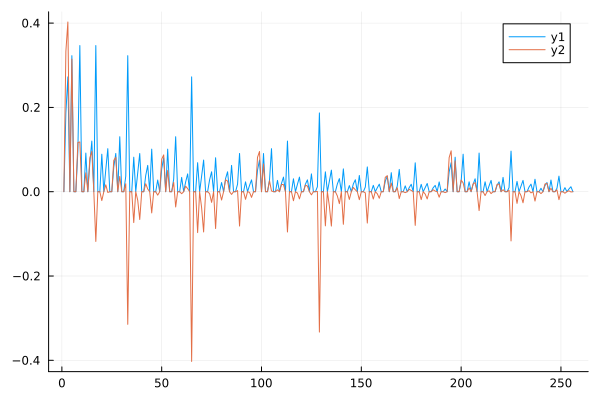

In [35]:
wavefunction0 = MPS_to_dense(M_GS)
wavefunction1 = MPS_to_dense(M_exc1)
plot(wavefunction1)  # examine whether components are positive
plot!(wavefunction2)  # examine whether components are positive

In [20]:
minimum(wavefunction)

2.1460279854196715e-11

In [63]:
# function entropy_von_neumann(psi::MPS, b::Int)
#     s = siteinds(psi)  
#     orthogonalize!(psi, b)
#     _,S = svd(psi[b], (linkind(psi, b-1), s[b]))
#     SvN = 0.0
#     for n in 1:dim(S, 1)
#     p = S[n,n]^2
#     SvN -= p * log(p)
#     end
#     return SvN
# end

# entropies = [entanglement_entropy(J1J2_psiMPS, i) for i in 1:(length(J1J2_psiMPS)-1)]

### Adding nosie

In [55]:
p1 = 1.0;
p2 = 1.0;

Sx = [0 1; 1 0]

i = 1
j = 5

A = M_exc2

Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(A, Ws1)

M2 = add_CP(M1, Sx, i)
M2 = add_CP(M2, Sx, j)

M2_norm = only(MPDO_norm(M2))

M1_acl = add_ancillas(M1)
M2_acl = add_ancillas(M2);

In [56]:
F0 = fidelity_op(M1, Sx, Sx, i, j) 
F0_mps = fidelity_op_mps(A, Sx, Sx, i, j)

println(F0)
println(F0_mps)

0.3000436617530291
0.1902877826228035


In [8]:
p1 = 0.2;
p2 = 0.4; # Get the two noisy states
Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(M_GS, Ws1)

Ws2 = Array{Float64,3}[purified_dephasing_channel(p2,[0,0,1]) for _ in 1:N]
M2 = add_noise_MPS(M_GS, Ws2);

M1_acl = add_ancillas(M1)
M2_acl = add_ancillas(M2);

In [14]:
p1 = 0.4;
p2 = 0.6; # Get the two noisy states
Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(M_GS, Ws1)

Ws2 = Array{Float64,3}[purified_dephasing_channel(p2,[1,0,1]) for _ in 1:N]
M2 = add_noise_MPS(M_GS, Ws2);

da = 3;
M1_acl = add_ancillas(M1; da=da)
M2_acl = add_ancillas(M2; da=da);

In [15]:
M1dense = MPDO_to_dense(M1);
M2dense = MPDO_to_dense(M2);

rho1dense = M1dense*M1dense'
rho2dense = M2dense*M2dense'
F0 = compute_fidelity(rho1dense,rho2dense)

0.6600835611529033

In [8]:
pur1 = LinearAlgebra.tr(rho1dense*rho1dense)
pur2 = LinearAlgebra.tr(rho2dense*rho2dense)
tr12 = LinearAlgebra.tr(rho1dense*rho2dense)
tr1212 = LinearAlgebra.tr(rho1dense*rho2dense*rho1dense*rho2dense);

sub_fidelity = tr12 + sqrt(2) * sqrt(tr12^2-tr1212)

super_fidelity = tr12 + sqrt((1-pur1)*(1-pur2));

@show pur1, pur2, tr12, tr1212
@show sub_fidelity, super_fidelity, F0^2;

(pur1, pur2, tr12, tr1212) = (0.5578635550097644, 0.3962676558401, 0.451097246247571, 0.19494370359774493)
(sub_fidelity, super_fidelity, F0 ^ 2) = (0.58182614109792, 0.9677519398026375, 0.9437984812659618)


In [9]:
sub_and_super_fidelity(M1,M2) ## 8 digits accuracy using MPO contraction

(max_bond_dim(MPO1), max_bond_dim(MPO2)) = (30, 28)


(0.581826278952202, 0.9677519135164019)

In [30]:
## Another example
let 
    Ws1 = Array{Float64,3}[purified_dephasing_channel(0.6,[0,0,1]) for _ in 1:N]
    M1 = add_noise_MPS(M_GS, Ws1)

    Ws2 = Array{Float64,3}[purified_dephasing_channel(0.6,[1,0,1]) for _ in 1:N]
    M2 = add_noise_MPS(M_GS, Ws2);

    M1dense = MPDO_to_dense(M1);
    M2dense = MPDO_to_dense(M2);

    rho1dense = M1dense*M1dense'
    rho2dense = M2dense*M2dense'
    F0 = compute_fidelity(rho1dense,rho2dense)
    @show F0

    pur1 = LinearAlgebra.tr(rho1dense*rho1dense)
    pur2 = LinearAlgebra.tr(rho2dense*rho2dense)
    tr12 = LinearAlgebra.tr(rho1dense*rho2dense)
    tr1212 = LinearAlgebra.tr(rho1dense*rho2dense*rho1dense*rho2dense);

    sub_fidelity = tr12 + sqrt(2) * sqrt(tr12^2-tr1212)

    super_fidelity = tr12 + sqrt((1-pur1)*(1-pur2));

    @show pur1, pur2, tr12, tr1212
    @show sub_fidelity, super_fidelity, F0^2;

    sub_and_super_fidelity(M1,M2) ## Here the bound is much weaker
end

F0 = 0.6499944917344131
(pur1, pur2, tr12, tr1212) = (0.3435138211318929, 0.21812660674094533, 0.1372512444956223, 0.017880892420459014)
(sub_fidelity, super_fidelity, F0 ^ 2) = (0.18100079752506643, 0.8536932004831801, 0.4224928392850781)
(max_bond_dim(MPO1), max_bond_dim(MPO2)) = (25, 25)


(0.18100080794980508, 0.8536931792876998)

In [49]:
F0 # let block does not change any variable in Main - so safe

0.6600835612556227

## Here starts the optimization with purification

In [76]:
compute_overlap(M1_acl,M2_acl)  ## fidelity of purification without optimization

0.5722051238562718

In [57]:
compute_overlap(M1,M2)  ## fidelity of purification without optimization

0.0

In [10]:
M2_interms, ovs = optimize_overlap_onefloor(M1_acl,M2_acl,[diagm(ones(16)) for _ in 1:2*N-3], debug=0); 

New overlap: 0.969090857002956


In [59]:
function random_U(d::Int, dt::Float64, N::Int)
    # without ancilla d=2, with ancilla d=4
    Us = Matrix[]
    for i in 1:2*N-3
        H = randn(d*d,d*d) + 1im*randn(d*d,d*d)
        H = (H+H')/2
        push!(Us, exp(im*dt*H))
    end
    return Us
end

random_U (generic function with 1 method)

In [ ]:
d = 4   
dt = 1.0;
Us = random_U(d, dt, N)
M2_interms, ovs = optimize_overlap_onefloor(complex(M1_acl),complex(M2_acl),Us, debug=0); 

New overlap: 0.9690908570029572


In [87]:
d = 2   
dt = 1.0;
Us = random_U(d, dt, N)
ovs2 = optimize_overlap_twofloor_sweep(complex(M1), complex(M2),Us,100,verbose=1);

Sweep: 1
New overlap: 0.5145557118173111
Max bond dim: 23
New overlap: 0.534634622659347
Max bond dim: 24
Sweep: 2
New overlap: 0.5461033024248271
Max bond dim: 24
New overlap: 0.5577866547100182
Max bond dim: 24
Sweep: 3
New overlap: 0.5706187469534524
Max bond dim: 24
New overlap: 0.5883773493818978
Max bond dim: 24
Sweep: 4
New overlap: 0.6129279948767365
Max bond dim: 23
New overlap: 0.6156788525168841
Max bond dim: 24
Sweep: 5
New overlap: 0.616886520918022
Max bond dim: 23
New overlap: 0.6178051982888214
Max bond dim: 24
Sweep: 6
New overlap: 0.618585277997413
Max bond dim: 23
New overlap: 0.6192819956149499
Max bond dim: 24
Sweep: 7
New overlap: 0.6199230588767027
Max bond dim: 23
New overlap: 0.6205237194220982
Max bond dim: 24
Sweep: 8
New overlap: 0.621093053167401
Max bond dim: 23
New overlap: 0.6216367720044884
Max bond dim: 24
Sweep: 9
New overlap: 0.6221582747536708
Max bond dim: 23
New overlap: 0.6226600647683486
Max bond dim: 24
Sweep: 10
New overlap: 0.6231432711488633

In [66]:
d = 4   
dt = 1.0;
Us = random_U(d, dt, N)
ovs = optimize_overlap_twofloor_sweep(complex(M1_acl),complex(M2_acl),Us,100,verbose=1,max_bd = 256); ## Ancilla version

Initial overlap: 4.564961652026507e-34
Sweep: 1
New overlap: 0.25750754925392394
Max bond dim: 119
New overlap: 0.27731176806747887
Max bond dim: 86
Sweep: 2
New overlap: 0.282169251136033
Max bond dim: 103
New overlap: 0.287493630190064
Max bond dim: 96
Sweep: 3
New overlap: 0.29130302197447616
Max bond dim: 85
New overlap: 0.2933830887635548
Max bond dim: 76
Sweep: 4
New overlap: 0.2944814170631001
Max bond dim: 75
New overlap: 0.2951058344378903
Max bond dim: 72
Sweep: 5
New overlap: 0.2955079518311373
Max bond dim: 71
New overlap: 0.2958046587473088
Max bond dim: 69
Sweep: 6
New overlap: 0.29604784595890904
Max bond dim: 69
New overlap: 0.29626032933869223
Max bond dim: 68
Sweep: 7
New overlap: 0.2964522149259891
Max bond dim: 68
New overlap: 0.29662790274096335
Max bond dim: 68
Sweep: 8
New overlap: 0.2967893476096861
Max bond dim: 68
New overlap: 0.2969373869959043
Max bond dim: 67
Sweep: 9
New overlap: 0.29707261607432484
Max bond dim: 67
New overlap: 0.29719547175869426
Max bon

In [64]:
d = 2   
dt = 1.0;
Us_down = random_U(d, dt, N)
Us_up = random_U(d, dt, N)
ovs = optimize_overlap_real_nfloor_sweep(complex(M1), complex(M2),[Us_down,Us_up],300,verbose=1);
# ovs = optimize_overlap_real_nfloor_sweep(M1, M2,[Us_down, Us_up],2,verbose=1);

Sweep: 1
New overlap: 0.07519881711659927
New overlap: 0.1255869728466674
Max bond dim: 120
New overlap: 0.1390498010433151
New overlap: 0.19300189498231765
Max bond dim: 103
Sweep: 2
New overlap: 0.21049756408748335
New overlap: 0.2455230288563876
Max bond dim: 96
New overlap: 0.25358186791671844
New overlap: 0.2656885188437963
Max bond dim: 84
Sweep: 3
New overlap: 0.26756229260466863
New overlap: 0.27109836806410204
Max bond dim: 82
New overlap: 0.2716434323409348
New overlap: 0.27355796948544114
Max bond dim: 79
Sweep: 4
New overlap: 0.2738921802806223
New overlap: 0.2748503033450133
Max bond dim: 78
New overlap: 0.27501632423280337
New overlap: 0.2757330696935423
Max bond dim: 76
Sweep: 5
New overlap: 0.27586490275922787
New overlap: 0.2764431759482401
Max bond dim: 76
New overlap: 0.2765740794653788
New overlap: 0.27706513547356304
Max bond dim: 73
Sweep: 6
New overlap: 0.2771626698011231
New overlap: 0.2776249321369217
Max bond dim: 73
New overlap: 0.2777413752995953
New overlap

16800-element Vector{Float64}:
 0.0020500704833581397
 0.01164751306142696
 0.016241338621402687
 0.021918367567670467
 0.025870916224929805
 0.03371781810133364
 0.04069365222061831
 0.04827821907923014
 0.049919541393038655
 0.05462419302454956
 ⋮
 0.2946763770291979
 0.2946763774854679
 0.2946763775666585
 0.294676377608867
 0.29467637822669046
 0.29467637004386227
 0.2946768601850519
 0.2946768781972509
 0.2946768789696572

In [20]:
# d = 4   
# dt = 1.0;
# Us_down = random_U(d, dt, N)
# Us_up = random_U(d, dt, N)
# ovs = optimize_overlap_real_nfloor_sweep(complex(M1_acl), complex(M2_acl),[Us_down, Us_up],2,verbose=1,max_bd = 256);

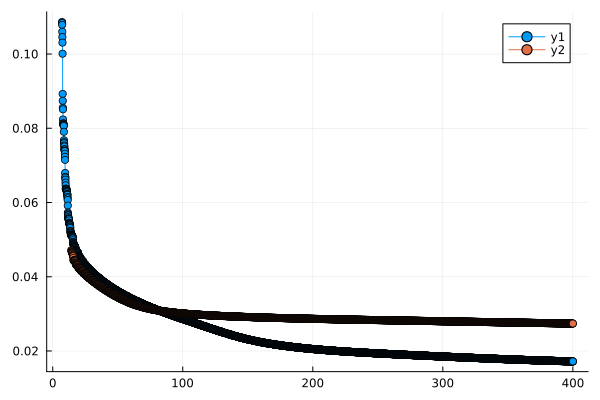

In [88]:
x = range(1,length(ovs))./14
y = abs.(ovs.- F0)
x2 = range(1,length(ovs2))./7
y2 = abs.(ovs2.- F0)
start = 100
start2 = 100
plot(x[start:end], y[start:end], marker = :circle)
plot!(x2[start2:end], y2[start2:end], marker = :circle)

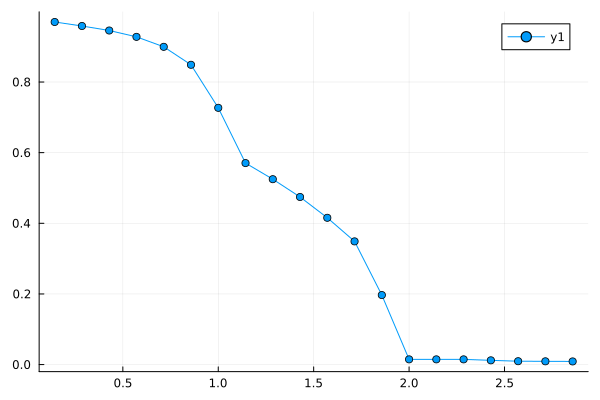

In [25]:
plot(x[1:20], y[1:20],marker = :circle)